# Assignment 4 Problem II: Helmholtz Steepest Descent #

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

import dolfin as dl
import ufl
from hippylib import nb

import numpy as np
import logging


logging.getLogger('FFC').setLevel(logging.WARNING)
logging.getLogger('UFL').setLevel(logging.WARNING)
dl.set_log_active(False)

np.random.seed(seed=42)

\begin{gather*}
  m(x,y) = \begin{cases}
    0.2 & \text{if} \; \sqrt{(x - 0.1)^2 + 2 (y + 0.2)^2} < 0.5 \\
    0 & \text{otherwise} \\
  \end{cases} \\
\end{gather*}


Refinement level 0; Number of mesh elements: 6402


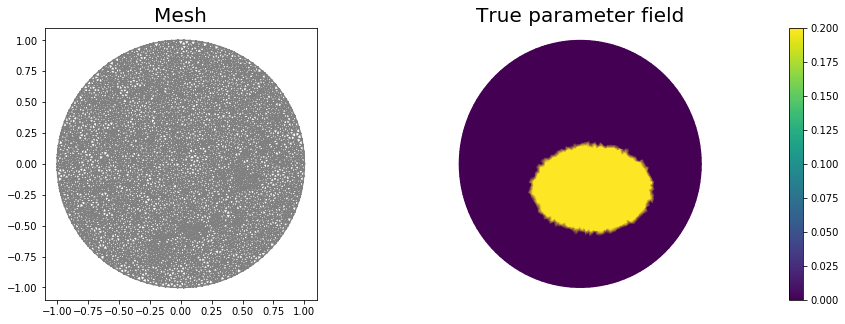

In [2]:
# create mesh and define function spaces
# mesh = dl.RectangleMesh(dl.Point(-1,-1),dl.Point(1,1), 32, 32)
mesh = dl.Mesh("circle.xml")
print("Refinement level 0; Number of mesh elements: {0}".format(mesh.num_cells()))

nrefinements = 0
for i in range(nrefinements):
    mesh = dl.refine(mesh)
    print("Refinement level {0}; Number of mesh elements: {1}".format(i+1, mesh.num_cells()))

Vm = dl.FunctionSpace(mesh, 'Lagrange', 1)
Vu = dl.FunctionSpace(mesh, 'Lagrange', 2)

# The true parameter, continuous and discretized/interpolated.
mtrue_cont = dl.Expression('0. + 0.2 * ((pow(x[0] - 0.1, 2) + 2*pow(x[1] + 0.2, 2)) < pow(0.5,2))', degree=5)
mtrue = dl.interpolate(mtrue_cont, Vm)

# plot
plt.figure(figsize=(15,5))
nb.plot(mesh, subplot_loc=121, mytitle="Mesh", show_axis='on')
nb.plot(mtrue, subplot_loc=122, mytitle="True parameter field")
plt.show()

The computational domain $\Omega = \{ x \in \mathbb{R}^2 \; | \; {\lVert x \rVert}^2 < 1 \}$ is the unit disc, $k_0 = 5$ is the wave number, and $\beta > 0$ is the regularization parameter. The incident wavefield $u^{\text{inc}}(x)$ is the superposition of three spherical waves with wave number $k_0$ generated by point-like sources. That is:

\begin{gather*}
  u^{\text{inc}}(x) = \sum\limits_{j=1}^{3} -e_i \frac{\cos (k_0 {\lvert x - x_i \rvert})}{4 \pi {\lvert x - x_i \rvert}} \\
\end{gather*}

where $x_i$ denote the locations of the three point-like sources and $e_i \sim N(0,1)$ are randomly chosen coefficients.

We will actually define $u_i$ for $\{1,2,3\}$ first, then multiply by the random number and combine in the next step.


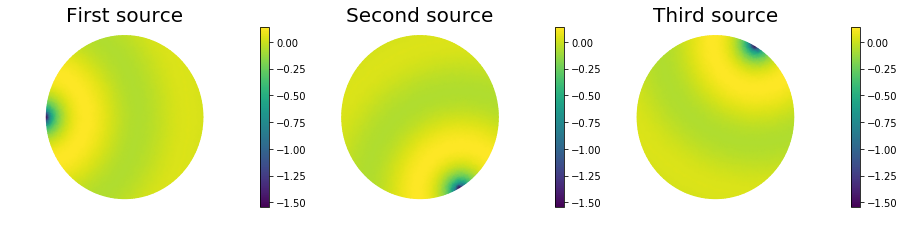

In [3]:
k0raw = 5.
k0sq = dl.Constant(k0raw*k0raw)
nsources = 3

def build_inc_wave(i):
    theta = -np.pi + 2*np.pi*i/nsources
    radius = 1.05
    xi = [radius*np.cos(theta), radius*np.sin(theta)]
    
    ei = np.random.normal()
    
    distance_source = dl.Expression("std::sqrt((x[0]-s0)*(x[0]-s0) + (x[1]-s1)*(x[1]-s1))",
                                    s0=xi[0], s1=xi[1], degree=1)
    u_i_exp = dl.Expression("-std::cos(k0*distance_source)/(4.*DOLFIN_PI*distance_source)",
                              k0=k0raw, distance_source=distance_source, degree=6)
    return dl.interpolate(u_i_exp, Vu)

# build_inc_wave(1)
u_is = [build_inc_wave(i) for i in range(nsources)]

# plot
plt.figure(figsize=(15,3.3))
nb.plot(u_is[0], subplot_loc=131, mytitle="First source")
nb.plot(u_is[1], subplot_loc=132, mytitle="Second source")
nb.plot(u_is[2], subplot_loc=133, mytitle="Third source")
plt.show()

## Source encoding

Source encoding is a common technique based on superposition of effects to reduce the computational cost of full-waveform inversion.

Simply put, source encoding exploits the linearity of the Helmholtz equation with respect to the source term and computes a single pressure field correspoding to the simulataneous exitation of all sources together. Here, we take the superimposed source $u_inc$ to be a random linear combination of all sources $u_i$. The weights $e_i$ of this linear combination are sampled from a i.i.d. Gaussian distribution. That is:

$$ u_{inc}(\boldsymbol{x}) = \sum_i e_i u_i(\boldsymbol{x}), \quad e_i \sim \mathcal{N}(0,1). $$

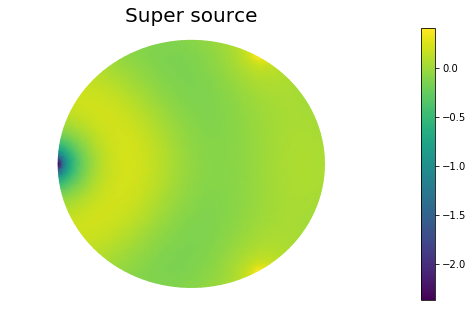

In [4]:
encoding = np.random.normal(size=nsources)

u_inc = dl.Function(Vu)

for i, u_i in enumerate(u_is):
    u_inc.vector().axpy(encoding[i], u_i.vector())
    
plt.figure(figsize=(7.5,5))
nb.plot(u_inc, mytitle="Super source")
plt.show()

In [5]:
# define trial/test/regular functions for parameter, state and adjoint
m, m_trial, m_test = dl.Function(Vm), dl.TrialFunction(Vm), dl.TestFunction(Vm)
u, u_trial, u_test = dl.Function(Vu), dl.TrialFunction(Vu), dl.TestFunction(Vu)
p, p_trial, p_test = dl.Function(Vu), dl.TrialFunction(Vu), dl.TestFunction(Vu)


The forward equation is the Helmholtz equation:

\begin{gather*}
  - \Delta u - k_0^2 (1 - \tanh(m)) u = k_0^2 \cdot \tanh(m) \cdot u^{\text{inc}}, \quad \text{in} \; \Omega \\
  \frac{\partial u}{\partial n} = 0, \quad \text{on} \; \Gamma \\
\end{gather*}


in weak form:

\begin{gather*}
%  - \int_\Omega \Delta u p \; d\vec{x} - \int_\Omega k_0^2 (1 - \tanh(m)) u p \; d\vec{x} = \int_\Omega k_0^2 \cdot \tanh(m) \cdot u^\text{inc} p \; d\vec{x} \\
  \int_\Omega \nabla u \nabla p \; d\vec{x} - \int_\Omega k_0^2 (1 - \tanh(m)) u p \; d\vec{x} = \int_\Omega k_0^2 \cdot \tanh(m) \cdot u^{\text{inc}} p \; d\vec{x}, \quad \forall p \in \mathcal{U} \\
\end{gather*}


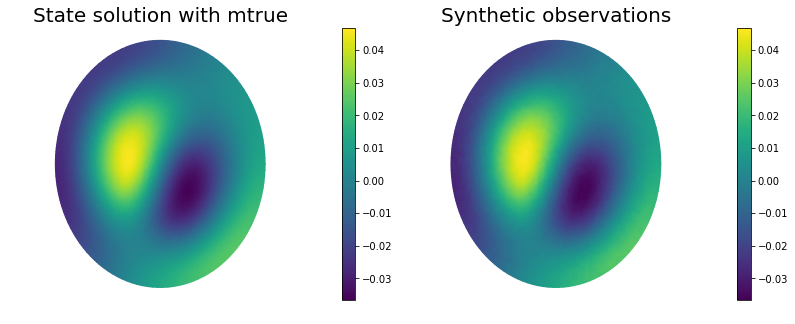

In [6]:
# noise level
noise_level = 0.01

forward_eq = ufl.inner(ufl.grad(u_trial), ufl.grad(u_test)) * ufl.dx \
        - k0sq * (dl.Constant(1.) - ufl.tanh(mtrue)) * u_trial * u_test * ufl.dx \
        - k0sq * ufl.tanh(mtrue) * u_inc * u_test * ufl.dx

# solve the forward/state problem to generate synthetic observations
bc_state = []
forward_lhsa, forward_rhsa = dl.assemble_system(ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)

utrue = dl.Function(Vu)
dl.solve(forward_lhsa, utrue.vector(), forward_rhsa)
assert np.all(np.isfinite(utrue.vector().get_local())), "State solution contains NaNs"


d = dl.Function(Vu)
d.assign(utrue)

# perturb state solution and create synthetic measurements d
# d = u + ||u||/SNR * random.normal
MAX = d.vector().norm("linf")
noise = dl.Vector()
forward_lhsa.init_vector(noise,1)
noise.set_local( noise_level * MAX * np.random.normal(0, 1, len(d.vector().get_local())) )

d.vector().axpy(1., noise)

# plot
nb.multi1_plot([utrue, d], ["State solution with mtrue", "Synthetic observations"])
plt.show()

Our cost function is as follows:

\begin{gather*}
  \min\limits_{m} \Phi (m) := \frac{1}{2}
  \int_\Gamma (u(m) - d)^2 \; ds
  + \frac{\beta}{2} \int_\Omega {\lVert \nabla m \rVert}^2 \; d\vec{x} \\
\end{gather*}


In [7]:
# Regularization parameter
gamma = 1e-4
beta = gamma

# Define cost function
def cost(u, d, m, gamma):
    misfit = 0.5 * dl.assemble( (u-d)**2*ufl.ds)
    reg = 0.5*gamma * dl.assemble( ufl.inner(dl.grad(m), ufl.grad(m))*ufl.dx ) 
    return [misfit + reg, misfit, reg]

Our forward equation in weak form. We covered this earlier, but we are redefining with $m$ instead of $m_{\text{true}}$

\begin{gather*}
  \int_\Omega \nabla u \nabla p \; d\vec{x} - \int_\Omega k_0^2 (1 - \tanh(m)) u p \; d\vec{x} = \int_\Omega k_0^2 \cdot \tanh(m) \cdot u^{\text{inc}} p \; d\vec{x}, \quad \forall p \in \mathcal{U} \\
\end{gather*}


In [8]:
# We defined this earlier, but now we define with variable m, not m_true.
# Given m, solve for u.
forward_eq = ufl.inner(ufl.grad(u_trial), ufl.grad(u_test)) * ufl.dx \
        - k0sq * (dl.Constant(1.) - ufl.tanh(m)) * u_trial * u_test * ufl.dx \
        - k0sq * ufl.tanh(m) * u_inc * u_test * ufl.dx

# set up dirichlet boundary conditions
def boundary(x,on_boundary):
    return on_boundary

bc_state = [] # dl.DirichletBC(Vu, dl.Constant(0.), boundary)

The first variation of the Lagrangian with respect to $u$ gives us the weak form of the adjoint equation:

\begin{gather*}
  (\mathcal{L}_u(u,m,p), \tilde{u}) :=
  \int_\Gamma (u - d) \tilde{u} \; d\vec{s}
  + \int_\Omega \nabla \tilde{u} \nabla p
  - k_0^2 (1 - \tanh(m)) \tilde{u} p
  \; d\vec{x}, \quad \forall \tilde{u} \in \mathcal{V} \\
\end{gather*}

In [9]:
# Given m, u, solve for adjoint p
# adjoint_eq = ufl.inner(u-d, p_test) * ufl.ds \
#     + ufl.inner(ufl.grad(p_test), ufl.grad(p_trial)) * ufl.dx \
#     - k0sq * (1. - ufl.tanh(m)) * p_test * p_trial * ufl.dx
adjoint_eq = (u - d) * p_test * ufl.ds \
   + ufl.inner(ufl.grad(p_trial), ufl.grad(p_test)) * ufl.dx \
   - k0sq * (1. - ufl.tanh(m)) * p_trial * p_test * ufl.dx


bc_adj = [] # The first term is the boundary condition.

The first variation of the Lagrangian with respect to $m$ gives us the weak form of the gradient of the objective when we use the corresponding $u,p$ from the state equation and adjoint equation:

\begin{gather*}
  (\mathcal{L}_m(u,m,p), \tilde{m}) :=
  \int_\Omega \beta \nabla m \nabla \tilde{m} \; d\vec{x}
  + \int_\Omega k_0^2 \cdot \tilde{m} / \cosh^2(m) \cdot u p \; d\vec{x}
  + \int_\Omega k_0^2 \cdot \tilde{m} / \cosh^2(m) \cdot u^{\text{inc}} p \; d\vec{x}
  , \quad \forall \tilde{m} \in \mathcal{M} \\
\end{gather*}

In [10]:
# Given m, u, p, solve for adjoint p
grad_reg = dl.Constant(beta) * ufl.inner(ufl.grad(m), ufl.grad(m_test)) * ufl.dx
grad_misfit = k0sq * m_test / ufl.cosh(m) / ufl.cosh(m) * u * p * ufl.dx \
    + k0sq * m_test / ufl.cosh(m) / ufl.cosh(m) * u_inc * p * ufl.dx


### Finite difference check of the gradient

We use a **finite difference check** to verify that our gradient derivation is correct.
Specifically, we consider a function $ m_0\in \mathcal{M}$ and we verify that for an arbitrary direction $\tilde{m} \in \mathcal{M}$ we have
$$ r := \left| \frac{ \mathcal{J}(m_0 + \varepsilon \tilde{m}) - \mathcal{J}(m_0)}{\varepsilon} -  \left(\mathcal{G}(m_0), \tilde{m}\right)\right| = \mathcal{O}(\varepsilon).$$

In the figure below we show in a loglog scale the value of $r$ as a function of $\varepsilon$. We observe that $r$ decays linearly for a wide range of values of $\varepsilon$, however we notice an increase in the error for extremely small values of $\varepsilon$ due to numerical stability and finite precision arithmetic.


State norm: 76.80193530256398
c0=1.7938174211844522
Adjoint norm: 444.48579533730305
grad0 norm: 1.0838157516397948


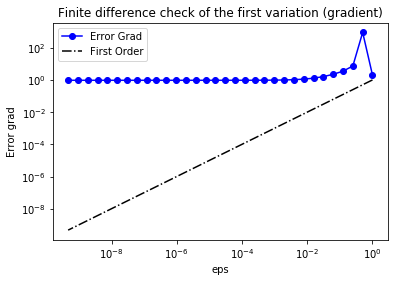

In [11]:
m0 = dl.interpolate(dl.Constant(np.log(4.) ), Vm )

n_eps = 32
eps = np.power(2., -np.arange(n_eps))
err_grad = np.zeros(n_eps)

m.assign(m0)

# Solve the fwd problem and evaluate the cost functional
A, state_b = dl.assemble_system (ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
dl.solve(A, u.vector(), state_b)
assert np.all(np.isfinite(u.vector().get_local())), "State solution contains NaNs"
print("State norm:", u.vector().norm("l2"))    

c0, _, _ = cost(u, d, m, gamma)
print(f"c0={c0}")

# Solve the adjoint problem and evaluate the gradient
adj_A, adjoint_RHS = dl.assemble_system(ufl.lhs(adjoint_eq), ufl.rhs(adjoint_eq), bc_adj)
dl.solve(adj_A, p.vector(), adjoint_RHS)
assert np.all(np.isfinite(p.vector().get_local())), "State solution contains NaNs"
print("Adjoint norm:", p.vector().norm("l2"))    

# evaluate the  gradient
grad0 = dl.assemble(grad_misfit + grad_reg)
print("grad0 norm:", grad0.norm("l2"))    

# Define an arbitrary direction m_hat to perform the check 
mtilde = dl.Function(Vm).vector()
mtilde.set_local(np.random.randn(Vm.dim()))
mtilde.apply("")
mtilde_grad0 = grad0.inner(mtilde)

for i in range(n_eps):
    m.assign(m0)
    m.vector().axpy(eps[i], mtilde)
    
    A, state_b = dl.assemble_system (ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
    dl.solve(A, u.vector(), state_b)
    assert np.all(np.isfinite(u.vector().get_local())), "State solution contains NaNs"
#     print("State norm:", u.vector().norm("l2"))

    cplus, _, _ = cost(u, d, m, gamma)
   
    err_grad[i] = abs( (cplus - c0)/eps[i] - mtilde_grad0 )

plt.figure()    
plt.loglog(eps, err_grad, "-ob", label="Error Grad")
plt.loglog(eps, (.5*err_grad[0]/eps[0])*eps, "-.k", label="First Order")
plt.title("Finite difference check of the first variation (gradient)")
plt.xlabel("eps")
plt.ylabel("Error grad")
plt.legend(loc = "upper left")
plt.show()

### Initial guess

We solve the state equation and compute the cost functional for the initial guess of the parameter ``m0``

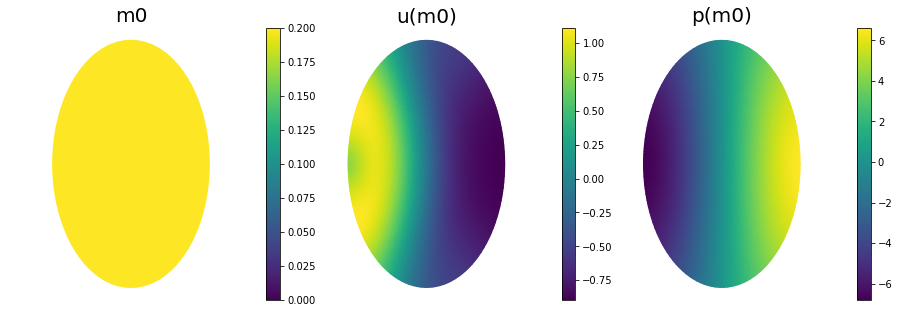

In [12]:
m.assign(m0)

# solve state equation
A, state_b = dl.assemble_system (ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
dl.solve(A, u.vector(), state_b)
assert np.all(np.isfinite(u.vector().get_local())), "State solution contains NaNs"

# solve the adoint problem
adj_A, adjoint_RHS = dl.assemble_system(ufl.lhs(adjoint_eq), ufl.rhs(adjoint_eq), bc_adj)
dl.solve(adj_A, p.vector(), adjoint_RHS)
assert np.all(np.isfinite(p.vector().get_local())), "State solution contains NaNs"


# evaluate cost
[cost_old, misfit_old, reg_old] = cost(u, d, m, gamma)

# plot
plt.figure(figsize=(15,5))
nb.plot(m, subplot_loc=131, mytitle="m0", vmin=mtrue.vector().min(), vmax=mtrue.vector().max())
nb.plot(u, subplot_loc=132, mytitle="u(m0)")
nb.plot(p, subplot_loc=133, mytitle="p(m0)")
plt.show()

## The steepest descent with Armijo line search:

We solve the constrained optimization problem using the steepest descent method with Armijo line search.

The stopping criterion is based on a relative reduction of the norm of the gradient (i.e. $\frac{\|g_{n}\|}{\|g_{0}\|} \leq \tau$).

The gradient is computed by solving the state and adjoint equation for the current parameter $m$, and then substituing the current state $u$, parameter $m$ and adjoint $p$ variables in the weak form expression of the gradient:

$$ (g, \tilde{m}) = \gamma(\nabla m, \nabla \tilde{m}) +(\tilde{m}e^m\nabla u, \nabla p).$$

Note that to obtain the expansion coefficient of the gradient $g$ in the finite element basis, we need to solve a linear system, where the left-hand side matrix is a mass matrix (stemming from finite element discretization of the $L^2$-inner product. In practice, we can also precondition the gradient descent direction by use of any symmetric positive definite operator $P$. For example, we can take $P$ as the finite element matrix stemming from discretization of the $H^1$-inner product.

The Armijo line search uses backtracking to find $\alpha$ such that a sufficient reduction in the cost functional is achieved.
Specifically, we use backtracking to find $\alpha$ such that:

$$J( m - \alpha g ) \leq J(m) - \alpha c_{\rm armijo} (g,g). $$


In [13]:
# Mass matrix in parameter space
Mvarf    = ufl.inner(m_trial, m_test) * ufl.dx
M = dl.assemble(Mvarf)

#  matrix in parameter space
Kvarf    = ufl.inner(m_trial, m_test) * ufl.dx + ufl.inner(ufl.grad(m_trial), ufl.grad(m_test)) * ufl.dx
K = dl.assemble(Kvarf)

Nit  cost          misfit        reg         ||grad||       alpha  N backtrack
  0   8.09038e-01   5.25841e-01   2.83197e-01   3.38478e+01   6.10352e-01    14


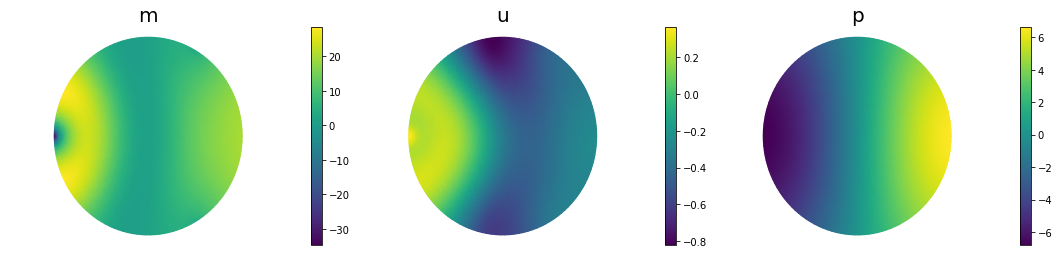

 10   7.59454e-01   4.86316e-01   2.73137e-01   9.18357e-01   2.14819e-03     1
 20   7.57627e-01   4.85585e-01   2.72042e-01   1.07225e+00   9.67777e-04     1
 30   7.56711e-01   4.85394e-01   2.71317e-01   8.01347e-01   8.71983e-04     1
 40   7.56187e-01   4.85348e-01   2.70839e-01   6.50027e-01   7.85671e-04     0
 50   7.55843e-01   4.85344e-01   2.70498e-01   7.80779e-01   3.53951e-04     2


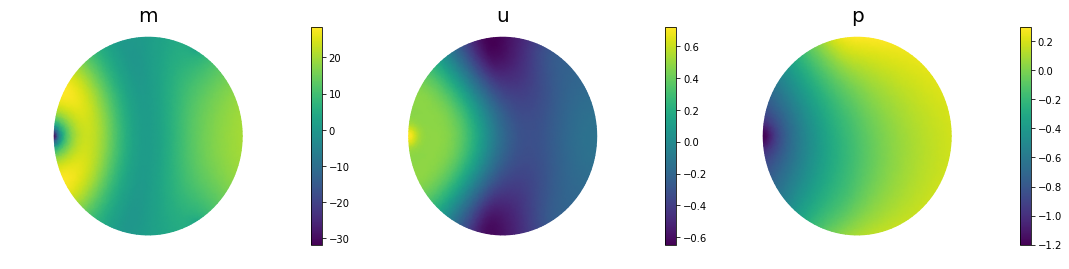

 60   7.55605e-01   4.85387e-01   2.70218e-01   7.34276e-01   3.18916e-04     1
 70   7.55420e-01   4.85437e-01   2.69983e-01   6.96136e-01   2.87348e-04     1
 80   7.55285e-01   4.85493e-01   2.69791e-01   8.14051e-01   2.58905e-04     1
 90   7.55165e-01   4.85553e-01   2.69612e-01   8.81506e-01   2.33278e-04     2
100   7.55066e-01   4.85591e-01   2.69475e-01   5.02877e-01   2.10187e-04     0


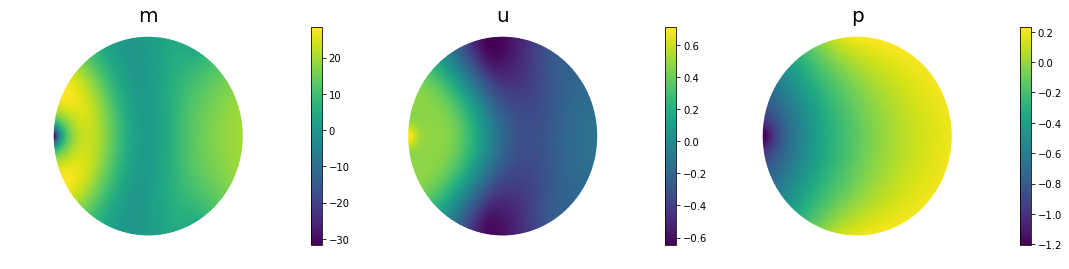

110   7.54981e-01   4.85661e-01   2.69320e-01   5.42284e-01   3.78764e-04     0
120   7.54911e-01   4.85699e-01   2.69212e-01   6.63244e-01   1.70636e-04     1
130   7.54856e-01   4.85740e-01   2.69116e-01   6.45423e-01   1.53746e-04     1
140   7.54808e-01   4.85778e-01   2.69029e-01   5.73551e-01   1.38528e-04     1
150   7.54764e-01   4.85819e-01   2.68945e-01   6.18876e-01   1.24816e-04     1


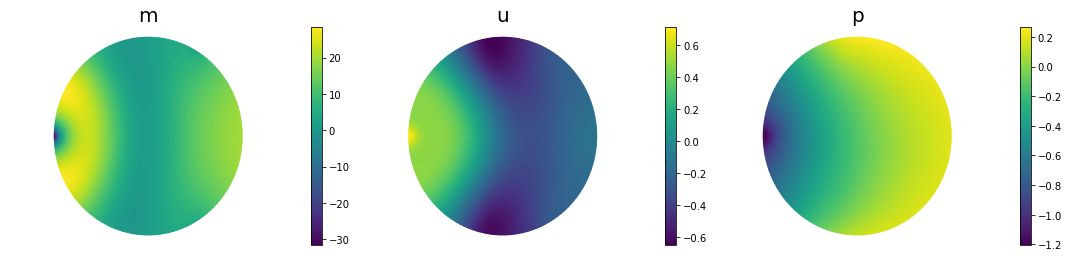

160   7.54725e-01   4.85855e-01   2.68869e-01   5.83523e-01   1.12461e-04     1
170   7.54689e-01   4.85894e-01   2.68795e-01   7.29682e-01   1.01329e-04     2
180   7.54656e-01   4.85928e-01   2.68727e-01   6.47559e-01   9.12992e-05     2
190   7.54629e-01   4.85959e-01   2.68670e-01   7.31058e-01   8.22621e-05     1
200   7.54604e-01   4.85986e-01   2.68618e-01   5.74566e-01   7.41195e-05     1


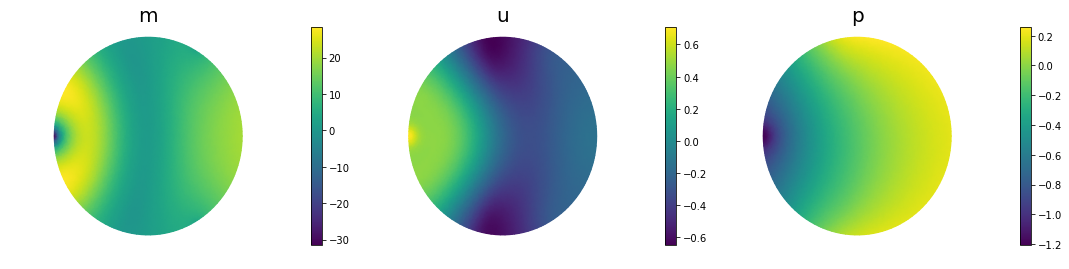

210   7.54580e-01   4.86017e-01   2.68562e-01   4.95396e-01   1.33566e-04     0
220   7.54557e-01   4.86045e-01   2.68512e-01   6.01092e-01   6.01724e-05     1
230   7.54539e-01   4.86074e-01   2.68465e-01   5.41512e-01   1.08433e-04     0
240   7.54522e-01   4.86099e-01   2.68423e-01   5.77051e-01   9.76996e-05     0
250   7.54503e-01   4.86122e-01   2.68381e-01   5.32468e-01   8.80289e-05     0


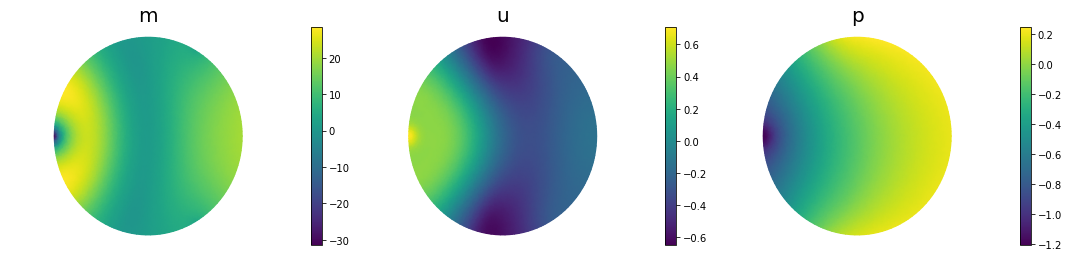

260   7.54488e-01   4.86143e-01   2.68345e-01   5.10173e-01   7.93155e-05     0
270   7.54474e-01   4.86164e-01   2.68310e-01   5.07964e-01   7.14646e-05     0
280   7.54460e-01   4.86188e-01   2.68273e-01   6.21342e-01   6.43907e-05     1
290   7.54447e-01   4.86205e-01   2.68242e-01   4.92758e-01   5.80171e-05     0
300   7.54435e-01   4.86225e-01   2.68211e-01   5.61123e-01   5.22743e-05     1


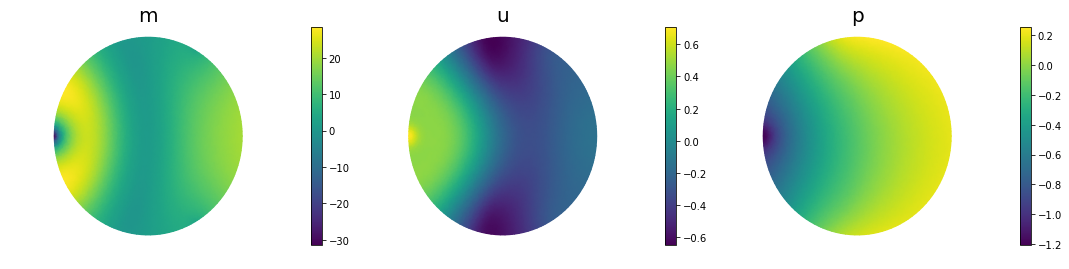

310   7.54424e-01   4.86242e-01   2.68182e-01   5.28548e-01   4.71000e-05     1
320   7.54415e-01   4.86262e-01   2.68153e-01   5.14806e-01   8.48758e-05     0
330   7.54403e-01   4.86278e-01   2.68126e-01   5.87455e-01   3.82372e-05     1
340   7.54394e-01   4.86294e-01   2.68100e-01   4.83350e-01   6.89047e-05     0
350   7.54386e-01   4.86312e-01   2.68073e-01   5.42560e-01   6.20843e-05     0


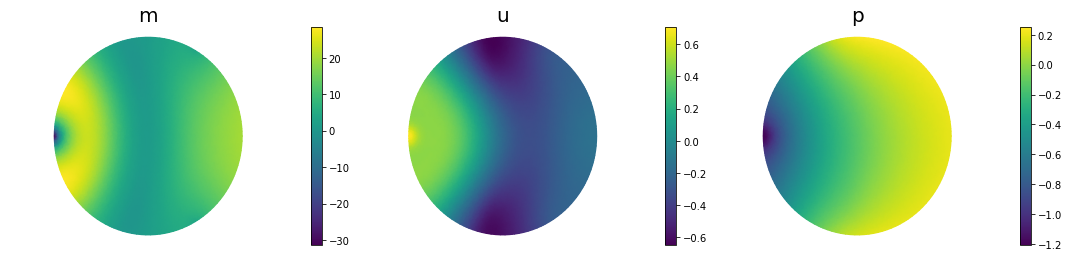

360   7.54376e-01   4.86325e-01   2.68051e-01   5.96274e-01   2.79695e-05     2
370   7.54368e-01   4.86342e-01   2.68026e-01   5.42510e-01   5.04019e-05     1
380   7.54361e-01   4.86355e-01   2.68005e-01   4.92689e-01   4.54129e-05     0
390   7.54353e-01   4.86370e-01   2.67983e-01   4.86359e-01   4.09178e-05     0
400   7.54346e-01   4.86383e-01   2.67963e-01   5.20936e-01   3.68676e-05     1


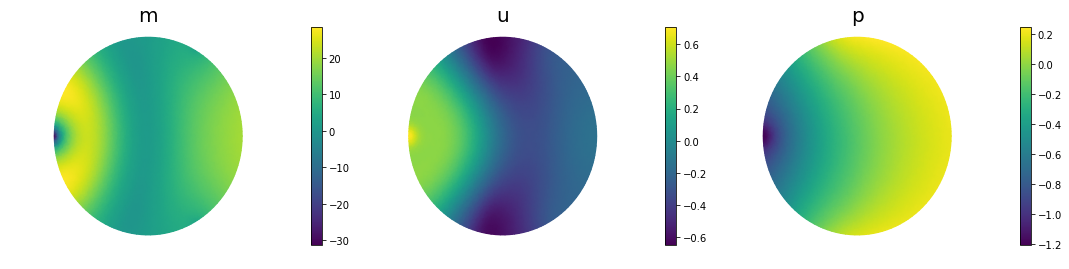

410   7.54340e-01   4.86397e-01   2.67943e-01   6.25633e-01   3.32183e-05     1
420   7.54334e-01   4.86410e-01   2.67924e-01   5.08445e-01   5.98605e-05     0
430   7.54327e-01   4.86422e-01   2.67904e-01   6.20368e-01   2.69676e-05     2
440   7.54322e-01   4.86435e-01   2.67887e-01   5.29266e-01   4.85965e-05     0
450   7.54316e-01   4.86447e-01   2.67869e-01   5.32878e-01   4.37863e-05     0


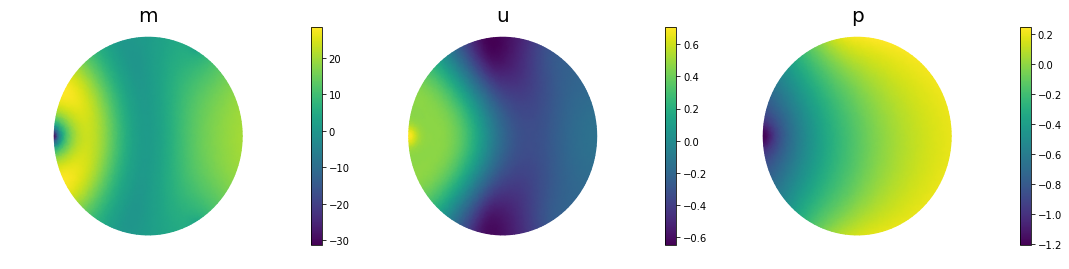

460   7.54310e-01   4.86456e-01   2.67854e-01   6.40465e-01   1.97261e-05     2
470   7.54305e-01   4.86467e-01   2.67838e-01   4.96198e-01   3.55470e-05     0
480   7.54300e-01   4.86478e-01   2.67822e-01   4.99902e-01   3.20284e-05     1
490   7.54295e-01   4.86488e-01   2.67807e-01   4.83833e-01   2.88581e-05     0
500   7.54291e-01   4.86498e-01   2.67792e-01   4.81535e-01   2.60017e-05     0


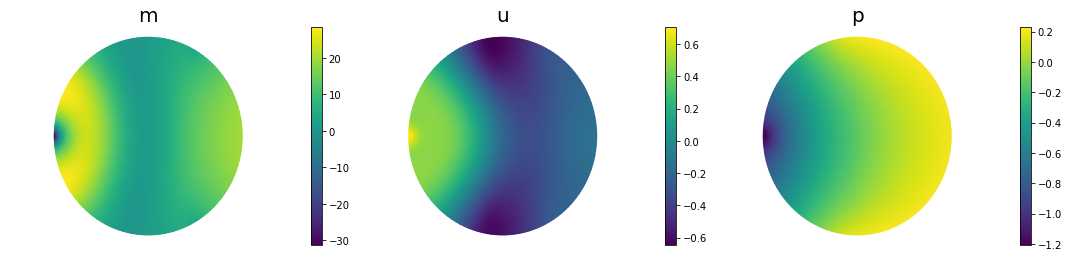

510   7.54286e-01   4.86509e-01   2.67777e-01   5.50888e-01   2.34279e-05     1
520   7.54282e-01   4.86518e-01   2.67764e-01   5.97822e-01   2.11089e-05     1
530   7.54278e-01   4.86527e-01   2.67751e-01   5.86701e-01   1.90195e-05     1
540   7.54274e-01   4.86536e-01   2.67738e-01   5.78168e-01   1.71369e-05     1
550   7.54270e-01   4.86545e-01   2.67725e-01   5.04253e-01   3.08812e-05     0


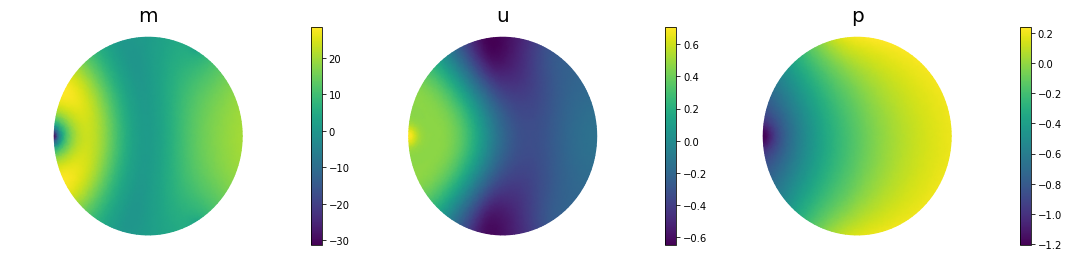

560   7.54267e-01   4.86554e-01   2.67713e-01   5.79627e-01   2.78245e-05     1
570   7.54263e-01   4.86562e-01   2.67702e-01   4.97038e-01   2.50703e-05     0
580   7.54259e-01   4.86571e-01   2.67689e-01   4.82600e-01   4.51775e-05     0
590   7.54256e-01   4.86578e-01   2.67678e-01   4.80240e-01   2.03528e-05     0
600   7.54253e-01   4.86586e-01   2.67666e-01   5.47442e-01   1.83382e-05     1


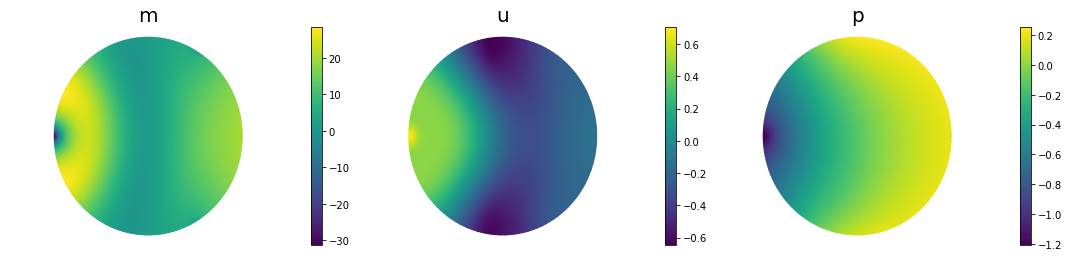

610   7.54250e-01   4.86594e-01   2.67656e-01   5.76581e-01   1.65230e-05     1
620   7.54247e-01   4.86601e-01   2.67646e-01   5.76684e-01   1.48875e-05     1
630   7.54244e-01   4.86608e-01   2.67636e-01   5.33481e-01   1.34139e-05     1
640   7.54241e-01   4.86615e-01   2.67626e-01   6.23296e-01   1.20861e-05     2
650   7.54238e-01   4.86622e-01   2.67617e-01   4.91340e-01   2.17796e-05     0


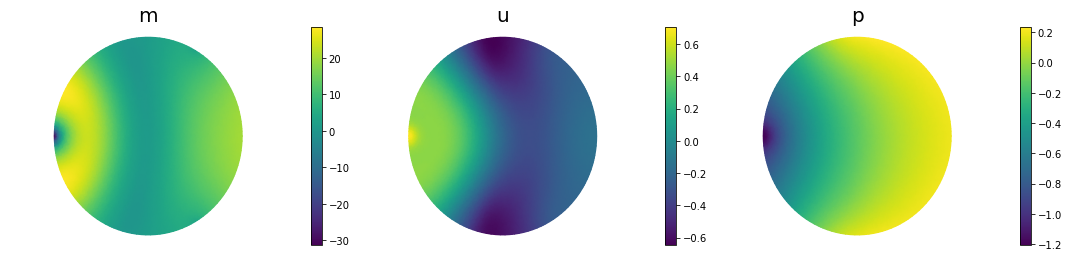

660   7.54236e-01   4.86629e-01   2.67607e-01   4.93117e-01   1.96238e-05     1
670   7.54233e-01   4.86636e-01   2.67597e-01   5.50324e-01   1.76813e-05     1
680   7.54230e-01   4.86642e-01   2.67588e-01   4.99811e-01   1.59312e-05     1
690   7.54228e-01   4.86649e-01   2.67579e-01   6.86504e-01   1.43543e-05     1
700   7.54225e-01   4.86655e-01   2.67570e-01   5.76366e-01   1.29334e-05     2


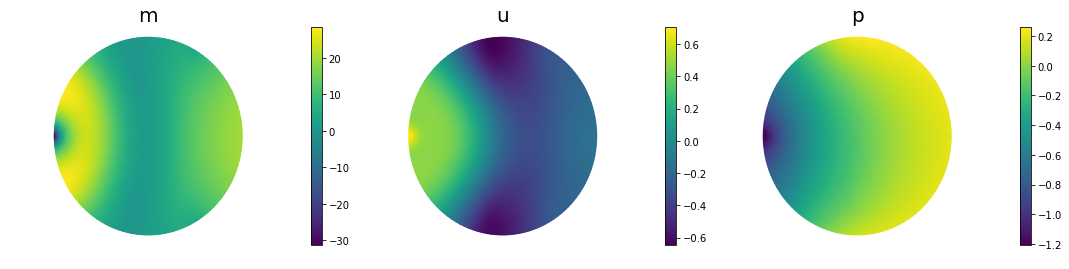

710   7.54223e-01   4.86661e-01   2.67562e-01   4.81041e-01   2.33064e-05     0
720   7.54221e-01   4.86667e-01   2.67554e-01   4.89396e-01   2.09995e-05     0
730   7.54219e-01   4.86673e-01   2.67546e-01   5.79425e-01   9.46043e-06     2
740   7.54216e-01   4.86679e-01   2.67538e-01   4.86208e-01   1.70480e-05     0
750   7.54214e-01   4.86685e-01   2.67529e-01   4.81647e-01   3.07211e-05     0


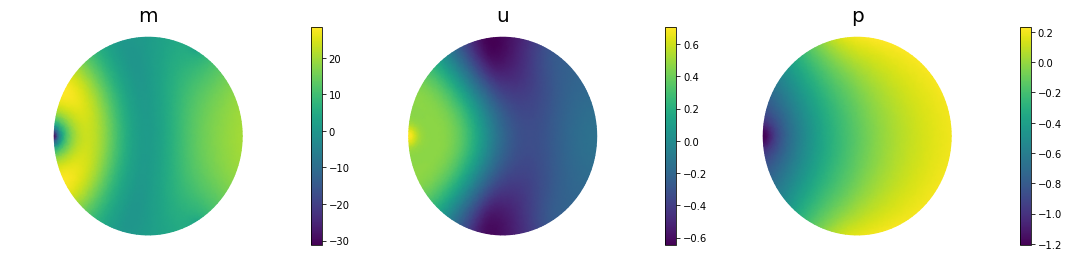

760   7.54212e-01   4.86690e-01   2.67522e-01   4.78759e-01   1.38401e-05     0
770   7.54210e-01   4.86696e-01   2.67514e-01   5.49116e-01   1.24701e-05     1
780   7.54208e-01   4.86701e-01   2.67507e-01   5.64956e-01   1.12358e-05     1
790   7.54206e-01   4.86706e-01   2.67500e-01   5.38267e-01   1.01236e-05     1
800   7.54204e-01   4.86712e-01   2.67493e-01   5.32911e-01   9.12157e-06     1


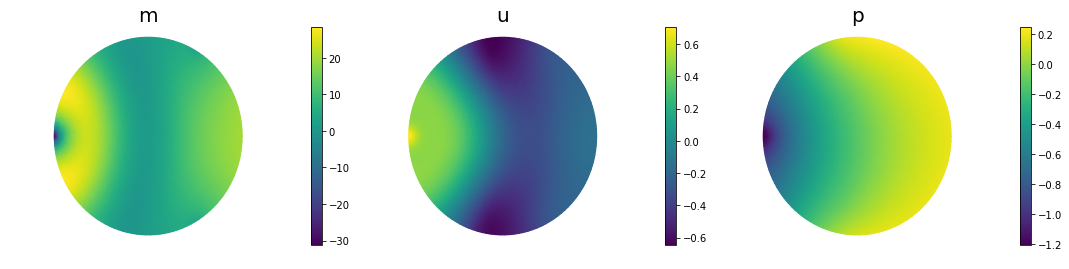

810   7.54202e-01   4.86717e-01   2.67486e-01   5.53740e-01   8.21868e-06     2
820   7.54201e-01   4.86722e-01   2.67479e-01   5.02791e-01   1.48103e-05     0
830   7.54199e-01   4.86727e-01   2.67472e-01   4.88087e-01   1.33443e-05     0
840   7.54197e-01   4.86732e-01   2.67466e-01   5.39385e-01   1.20235e-05     1
850   7.54196e-01   4.86736e-01   2.67459e-01   5.95973e-01   1.08333e-05     1


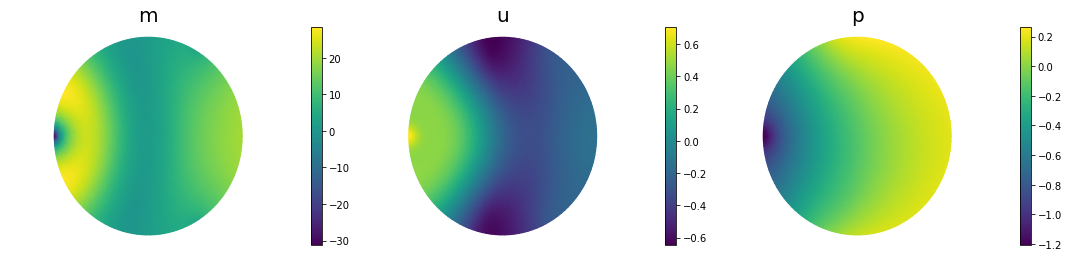

860   7.54194e-01   4.86741e-01   2.67453e-01   6.26222e-01   9.76102e-06     1
870   7.54192e-01   4.86745e-01   2.67447e-01   5.89348e-01   8.79484e-06     1
880   7.54191e-01   4.86749e-01   2.67442e-01   5.32547e-01   7.92429e-06     1
890   7.54189e-01   4.86754e-01   2.67436e-01   5.78630e-01   7.13991e-06     2
900   7.54188e-01   4.86758e-01   2.67429e-01   5.05066e-01   1.28664e-05     1


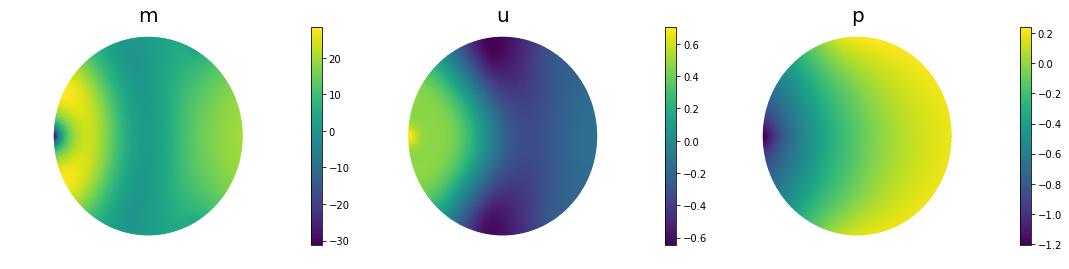

910   7.54186e-01   4.86763e-01   2.67423e-01   4.82258e-01   2.31856e-05     0
920   7.54185e-01   4.86767e-01   2.67418e-01   5.21662e-01   1.04453e-05     1
930   7.54184e-01   4.86771e-01   2.67413e-01   6.07766e-01   9.41138e-06     1
940   7.54182e-01   4.86775e-01   2.67407e-01   6.40861e-01   8.47981e-06     1
950   7.54181e-01   4.86779e-01   2.67402e-01   5.94033e-01   7.64044e-06     1


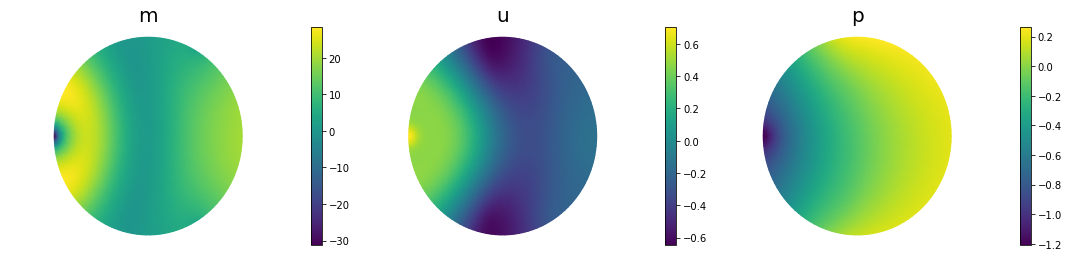

960   7.54180e-01   4.86782e-01   2.67397e-01   5.28223e-01   6.88416e-06     1
970   7.54178e-01   4.86786e-01   2.67392e-01   5.56576e-01   6.20274e-06     2
980   7.54177e-01   4.86790e-01   2.67387e-01   5.03058e-01   1.11775e-05     0
990   7.54176e-01   4.86794e-01   2.67382e-01   4.85638e-01   1.00712e-05     0
Steepest descent did not converge in  1000  iterations


In [14]:
# define parameters for the optimization
tol = 1e-4         # Relative tolerance on the gradient norm
maxiter = 1000     # Maximum number of iterations (we need a lot!)
print_any = 10     # We will only print progress on screen every few iterations
plot_any = 50      # We will plot the current solution every few iterations
c_armijo = 1e-3    # The Armijo constant to ensure sufficient descent
alpha = 1.e4       # The initial step-size

# initialize iter counters
iter = 0
converged = False

# initializations
g = dl.Vector()
M.init_vector(g,0)

m_prev = dl.Function(Vm)

#Select whether to use the L^2 inner product (mass matrix M)
# or to precondition steepest descent using the H^1 inner product (stiffness matrix K)
P = M
# P = K

print( "Nit  cost          misfit        reg         ||grad||       alpha  N backtrack" )

while iter <  maxiter and not converged:

    # solve the adoint problem
    adj_A, adjoint_RHS = dl.assemble_system(ufl.lhs(adjoint_eq), ufl.rhs(adjoint_eq), bc_adj)
    dl.solve(adj_A, p.vector(), adjoint_RHS)
    assert np.all(np.isfinite(p.vector().get_local())), "State solution contains NaNs"

    # Debug - print norms of state and adjoint
#     print("State norm:", u.vector().norm("l2"))
#     print("Adjoint norm:", p.vector().norm("l2"))    
    
    # evaluate the  gradient
    MG = dl.assemble(grad_misfit + grad_reg)
    dl.solve(P, g, MG)
    assert np.all(np.isfinite(g.get_local())), "State solution contains NaNs"

    # calculate the norm of the gradient
    grad_norm2 = g.inner(MG)
    gradnorm = np.sqrt(grad_norm2)
    
    if iter == 0:
        gradnorm0 = gradnorm

    # linesearch
    it_backtrack = 0
    m_prev.assign(m)
    
#     print("==== Iteration", iter, "====")
#     print("Cost_old:", cost_old)
#     print("Grad_norm2:", grad_norm2)
#     print("Alpha (before line search):", alpha)    
    
    backtrack_converged = False
    for it_backtrack in range(20):
        m.vector().axpy(-alpha, g )

        # solve the forward problem
        state_A, state_b = dl.assemble_system (ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
        dl.solve(state_A, u.vector(), state_b)
        assert np.all(np.isfinite(u.vector().get_local())), "State solution contains NaNs"

        # evaluate cost
        [cost_new, misfit_new, reg_new] = cost(u, d, m, gamma)

#         print(f"Backtrack {it_backtrack}: cost_new = {cost_new}, expected ≤ {cost_old - alpha * c_armijo * grad_norm2}")

        # check if Armijo conditions are satisfied
        if cost_new < cost_old - alpha * c_armijo * grad_norm2:
            cost_old = cost_new
            backtrack_converged = True
            break
        else:
            alpha *= 0.5
            m.assign(m_prev)  # reset m
            
    if backtrack_converged == False:
        print( "Backtracking failed. A sufficient descent direction was not found" )
        converged = False
        break

    sp = ""
    if (iter % print_any)== 0 :
        print( "%3d %1s %8.5e %1s %8.5e %1s %8.5e %1s %8.5e %1s %8.5e %1s %3d" % \
            (iter, sp, cost_new, sp, misfit_new, sp, reg_new, sp, \
            gradnorm, sp, alpha, sp, it_backtrack) )

    if (iter % plot_any)== 0 :
        nb.multi1_plot([m,u,p], ["m","u","p"], same_colorbar=False)
        plt.show()
    
    # check for convergence
    if gradnorm < tol*gradnorm0 and iter > 0:
        converged = True
        print ("Steepest descent converged in ",iter,"  iterations")
    
    alpha *= 1.5    # Try to increase the step size for the next iteration
    iter += 1
    
if not converged:
    print ( "Steepest descent did not converge in ", maxiter, " iterations")